In [2]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [5]:
# ==========================================
# CONFIGURATION
# ==========================================
# REPLACE THIS with the path to a SPECIFIC PATIENT folder
PATIENT_FOLDER = "./ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00000-000"
# Set to None to automatically pick the middle slice
# Set to an integer (e.g., 80) to pick a specific slice
SLICE_INDEX = 74 

SUFFIXES = {
    'T1 Native': '-t1n.nii.gz',
    'T1 Contrast': '-t1c.nii.gz',
    'T2 Weighted': '-t2w.nii.gz',
    'FLAIR': '-t2f.nii.gz'
}

COLORS = {
    'T1 Native': '#d62728', # Red
    'T1 Contrast': '#ff7f0e', # Orange
    'T2 Weighted': '#2ca02c', # Green
    'FLAIR': '#1f77b4'  # Blue
}

Processing Axial Slice for: BraTS-GLI-00000-000


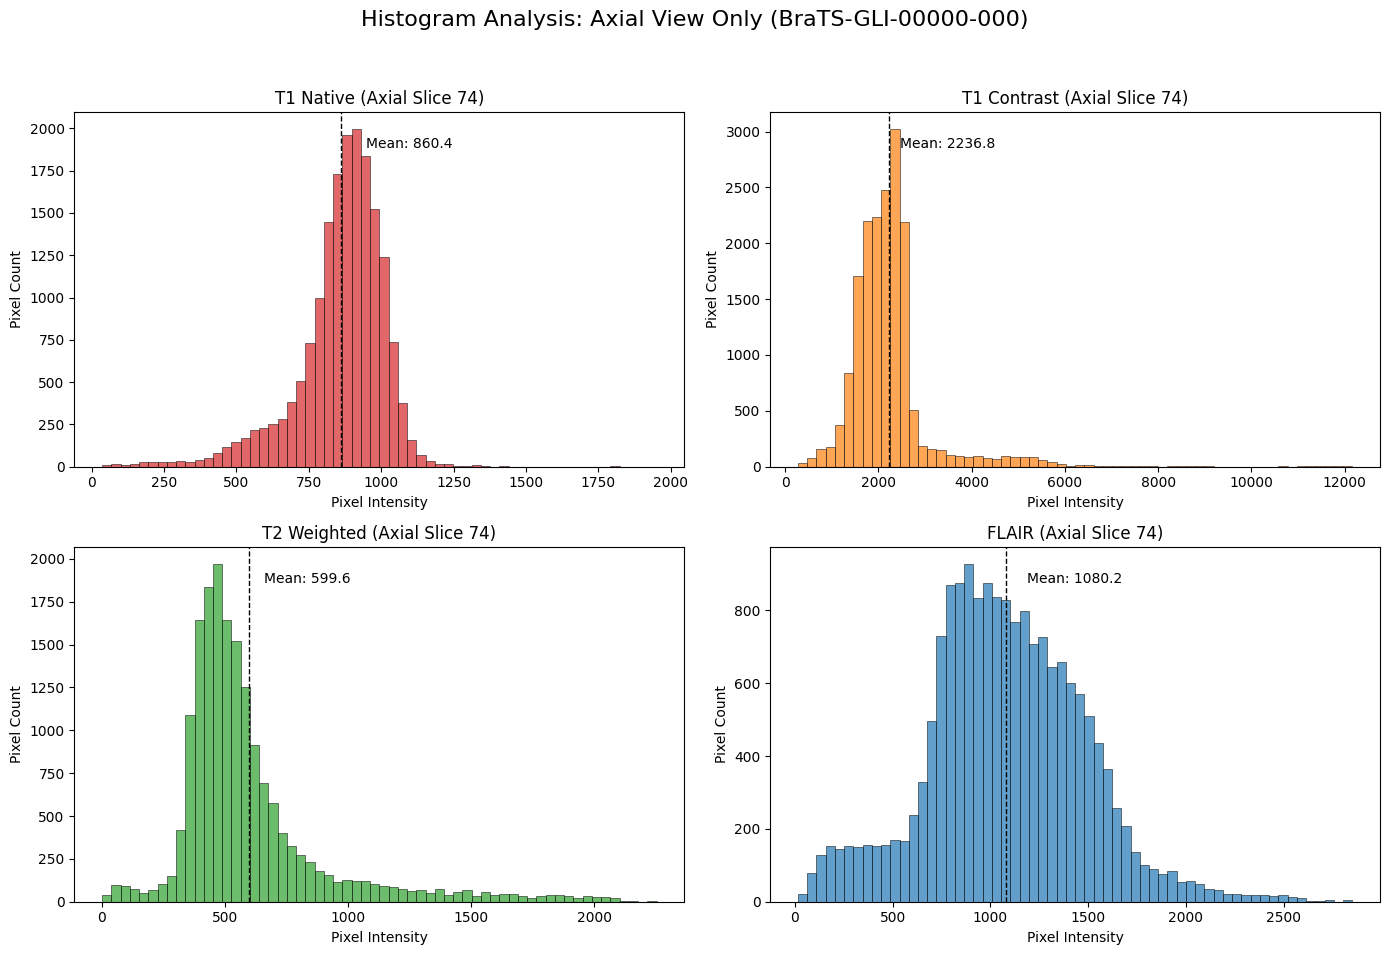

In [6]:
def analyze_axial_slice(patient_path, specific_slice=None):
    if not os.path.exists(patient_path):
        print(f"Error: Folder not found at {patient_path}")
        return

    patient_id = os.path.basename(patient_path)
    print(f"Processing Axial Slice for: {patient_id}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for idx, (modality_name, suffix) in enumerate(SUFFIXES.items()):
        filename = f"{patient_id}{suffix}"
        filepath = os.path.join(patient_path, filename)
        ax = axes[idx]

        if os.path.exists(filepath):
            # 1. Load 3D Volume
            img = nib.load(filepath)
            data = img.get_fdata()

            # 2. Determine Axial Slice Index (Z-axis is index 2)
            if specific_slice is None:
                z_index = data.shape[2] // 2
            else:
                z_index = int(specific_slice)
                # Bounds check
                z_index = max(0, min(z_index, data.shape[2] - 1))

            # 3. Extract 2D Axial Slice
            # Orientation: [x, y, z] -> we want [:, :, z_index]
            axial_slice = data[:, :, z_index]

            # 4. Flatten and Filter
            # We filter out exactly 0 (background) to see tissue contrast
            tissue_pixels = axial_slice[axial_slice > 0].flatten()

            if len(tissue_pixels) == 0:
                ax.text(0.5, 0.5, "Slice is Empty (Background only)", ha='center')
                ax.set_title(f"{modality_name} - Slice {z_index}")
                continue

            # 5. Plot Histogram
            ax.hist(tissue_pixels, bins=60, color=COLORS[modality_name], alpha=0.7, edgecolor='black', linewidth=0.5)
            
            # Formatting
            ax.set_title(f"{modality_name} (Axial Slice {z_index})")
            ax.set_xlabel("Pixel Intensity")
            ax.set_ylabel("Pixel Count")
            
            # Add mean intensity marker
            mean_val = np.mean(tissue_pixels)
            ax.axvline(mean_val, color='black', linestyle='dashed', linewidth=1)
            ax.text(mean_val*1.1, ax.get_ylim()[1]*0.9, f"Mean: {mean_val:.1f}")

        else:
            ax.text(0.5, 0.5, "File Missing", ha='center')
            ax.set_title(f"{modality_name}")

    plt.suptitle(f"Histogram Analysis: Axial View Only ({patient_id})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    analyze_axial_slice(PATIENT_FOLDER, SLICE_INDEX)